In [ ]:
# ==============================
# 1. Fix SSL Certificate Issues
# ==============================

# Reinstall CA certificates to fix any SSL issues
!sudo apt-get install --reinstall ca-certificates -y
!sudo update-ca-certificates --fresh

# =========================================
# 2. Optional SSL Context Workaround (If Needed)
# =========================================

import ssl
# This workaround bypasses SSL verification. **Use with caution**, as it can expose you to security risks.
ssl._create_default_https_context = ssl._create_unverified_context

# ==============================
# 3. Mount Google Drive
# ==============================

from google.colab import drive
drive.mount('/content/drive')

# =====================================================
# 4. Set the TORCH_HOME Environment Variable Correctly
# =====================================================

import os

# Set TORCH_HOME to point to your Google Drive cache directory
os.environ["TORCH_HOME"] = "/content/drive/My Drive/Colab_Notebooks/torch_cache"

# =====================================================
# 5. Create 'hub/checkpoints' Directories within TORCH_HOME
# =====================================================

# Define the path for hub/checkpoints
hub_checkpoints_dir = os.path.join(os.environ["TORCH_HOME"], "hub", "checkpoints")
os.makedirs(hub_checkpoints_dir, exist_ok=True)

# ===============================================
# 6. Move Pre-downloaded Weights to hub/checkpoints/
# ===============================================

import shutil

# Define source and destination directories
source_dir = os.path.join(os.environ["TORCH_HOME"], "checkpoints")
destination_dir = hub_checkpoints_dir

# List of weight files you have pre-downloaded
weight_files = [
    "senet154-c7b49a05.pth",
    "res2net50_26w_4s-06e79181.pth"
    # Add any other weight filenames you have here
]

for weight_file in weight_files:
    src_path = os.path.join(source_dir, weight_file)
    dest_path = os.path.join(destination_dir, weight_file)
    if os.path.exists(src_path) and not os.path.exists(dest_path):
        shutil.move(src_path, dest_path)
        print(f"Moved {weight_file} to hub/checkpoints/")
    elif os.path.exists(dest_path):
        print(f"{weight_file} already exists in hub/checkpoints/")
    else:
        print(f"{weight_file} not found in {source_dir}")

# ================================================
# 7. Install Required Libraries (Reinstall Every Session)
# ================================================

# Install segmentation_models_pytorch from GitHub
!pip install git+https://github.com/qubvel/segmentation_models.pytorch.git --quiet

# Install specific version of timm
!pip install timm==0.9.7 --quiet

# Install torchmetrics for evaluation metrics
!pip install torchmetrics --quiet

# Install Optuna for hyperparameter optimization
!pip install optuna --quiet

# =======================================================
# 8. Import Libraries After Setting Up TORCH_HOME
# =======================================================

# Standard Library Imports
import json
import re
from dataclasses import dataclass
import csv
from datetime import datetime

# Third-Party Library Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor, ToPILImage, Resize, Compose, Normalize
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import pandas as pd

# Metrics and Optimization Libraries
from torchmetrics.classification import BinaryF1Score, BinaryJaccardIndex
from sklearn.metrics import f1_score
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Segmentation Models PyTorch (smp)
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.metrics.functional import iou_score, f1_score

# AMP and Mixed Precision
from torch.amp import autocast, GradScaler  # Correct import for AMP

# Optuna for Hyperparameter Optimization
import optuna
from optuna.trial import TrialState

# ==============================
# 9. Verify Directory Structure and File Integrity
# ==============================

# Verify that weight files are in 'hub/checkpoints' and have correct sizes
for weight_file in weight_files:
    weight_path = os.path.join(hub_checkpoints_dir, weight_file)
    if os.path.exists(weight_path):
        size_mb = os.path.getsize(weight_path) / (1024 * 1024)
        print(f"{weight_file} size: {size_mb:.2f} MB")
    else:
        print(f"{weight_file} does not exist in hub/checkpoints/")

# ==============================
# 10. Final Verification - Initialize a Model Without Downloading
# ==============================

import torch
import segmentation_models_pytorch as smp

# Initialize device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    # Initialize the model
    model = smp.Unet(encoder_name='senet154', in_channels=3, classes=1, encoder_weights='imagenet').to(device)

    # Create a dummy input tensor
    dummy_input = torch.randn(1, 3, 256, 256).to(device)

    # Set model to evaluation mode and perform a forward pass
    model.eval()
    with torch.no_grad():
        output = model(dummy_input)

    print("\nModel initialized successfully without downloading weights.")
except Exception as e:
    print(f"Error initializing model: {e}")

print()
# If the above prints "Model initialized successfully without downloading weights.", you're all set!


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
0 upgraded, 0 newly installed, 1 reinstalled, 0 to remove and 49 not upgraded.
Need to get 162 kB of archives.
After this operation, 0 B of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 ca-certificates all 20240203~22.04.1 [162 kB]
Fetched 162 kB in 1s (218 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
(Reading database ... 123635 files and directories currently installed.)
Preparing to unpack .../ca-certificates_20240203~22.04.1_all.de

Mounting Google Drive...

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Number of training images: 80
 Number of training masks: 80
 Number of validation images: 20
 Number of validation masks: 20

Configuration, using Mini datasets : False
  Perform Hyperparameter Optimization: False
Number of Epochs for Training: 40

Train the Model: True
Create Submission File: True

Using device: cuda:0
Loading best parameters from file: /content/drive/MyDrive/Colab_Notebooks/saved_models/best_hyperparameters.json
Using best hyperparameters: {'weight_decay': 1.3210914896979222e-05, 'learning_rate': 0.0003462176239281892, 'max_norm': 1.4826980271166088, 'patience': 5, 'factor': 0.8668350381139165, 'batch_size': 16, 'loss': 'JaccardLoss', 'encoder_name': 'resnet34'}


Total Training Progress:   0%|          | 0/40 [00:00<?, ?it/s]


Epoch [1/40]



Epoch 1/40 Training: 100%|██████████| 60/60 [00:09<00:00,  6.87it/s]
                                                                    

Evaluating Thresholds:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating Thresholds:   0%|          | 0/16 [00:01<?, ?it/s, Threshold=0.10, Avg F1=0.7483]

Evaluating Thresholds:   6%|▋         | 1/16 [00:01<00:18,  1.26s/it, Threshold=0.10, Avg F1=0.7483]

Evaluating Thresholds:   6%|▋         | 1/16 [00:02<00:18,  1.26s/it, Threshold=0.15, Avg F1=0.8151]

Evaluating Thresholds:  12%|█▎        | 2/16 [00:02<00:17,  1.25s/it, Threshold=0.15, Avg F1=0.8151]

Evaluating Thresholds:  12%|█▎        | 2/16 [00:03<00:17,  1.25s/it, Threshold=0.20, Avg F1=0.8242]

Evaluating Thresholds:  19%|█▉        | 3/16 [00:03<00:16,  1.26s/it, Threshold=0.20, Avg F1=0.8242]

Evaluating Thresholds:  19%|█▉        | 3/16 [00:05<00:16,  1.26s/it, Threshold=0.25, Avg F1=0.8267]

Evaluating Thresholds:  25%|██▌       | 4/16 [00:05<00:15,  1.26s/it, Threshold=0.25, Avg F

Best threshold for Epoch 1: 0.30
Updated threshold range: [0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34]
Saved new best model to /content/drive/MyDrive/Colab_Notebooks/saved_models/UnetPlusPlus_resnet34_best_model.pth with F1 Score: 0.8209


...

Epoch [38/40] Summary:
Train Loss: 0.0338
Validation Loss: 0.1747
Validation F1 Score: 0.9022
Validation IoU Score: 0.8263
Best Threshold So Far: 0.15
Best F1 Score So Far: 0.9040 (IoU: 0.8281)

Epoch [39/40]



Total Training Progress:  98%|█████████▊| 39/40 [08:02<00:10, 10.98s/it, Val Loss=0.1728, Best F1=0.9040]

Epoch [39/40] Summary:
Train Loss: 0.0301
Validation Loss: 0.1728
Validation F1 Score: 0.9037
Validation IoU Score: 0.8283
Best Threshold So Far: 0.15
Best F1 Score So Far: 0.9040 (IoU: 0.8281)

Epoch [40/40]



Epoch 40/40 Training: 100%|██████████| 60/60 [00:09<00:00,  6.89it/s]
                                                                     

Evaluating Thresholds:   0%|          | 0/11 [00:00<?, ?it/s]

Evaluating Thresholds:   0%|          | 0/11 [00:01<?, ?it/s, Threshold=0.10, Avg F1=0.9016]

Evaluating Thresholds:   9%|▉         | 1/11 [00:01<00:12,  1.29s/it, Threshold=0.10, Avg F1=0.9016]

Evaluating Thresholds:   9%|▉         | 1/11 [00:02<00:12,  1.29s/it, Threshold=0.11, Avg F1=0.9016]

Evaluating Thresholds:  18%|█▊        | 2/11 [00:02<00:11,  1.27s/it, Threshold=0.11, Avg F1=0.9016]

Evaluating Thresholds:  18%|█▊        | 2/11 [00:03<00:11,  1.27s/it, Threshold=0.12, Avg F1=0.9015]

Evaluating Thresholds:  27%|██▋       | 3/11 [00:03<00:10,  1.26s/it, Threshold=0.12, Avg F1=0.9015]

Evaluating Thresholds:  27%|██▋       | 3/11 [00:05<00:10,  1.26s/it, Threshold=0.13, Avg F1=0.9015]

Evaluating Thresholds:  36%|███▋      | 4/11 [00:05<00:08,  1.26s/it, Threshold=0.13, Avg

Best threshold for Epoch 40: 0.10
Updated threshold range: [0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15]
Epoch [40/40] Summary:
Train Loss: 0.0293
Validation Loss: 0.1760
Validation F1 Score: 0.9015
Validation IoU Score: 0.8251
Best Threshold So Far: 0.10
Best F1 Score So Far: 0.9040 (IoU: 0.8281)

Generating final training plots...


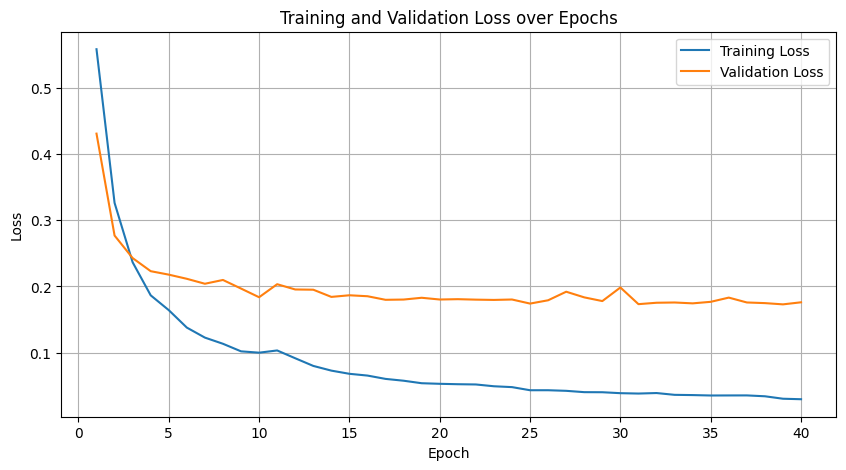

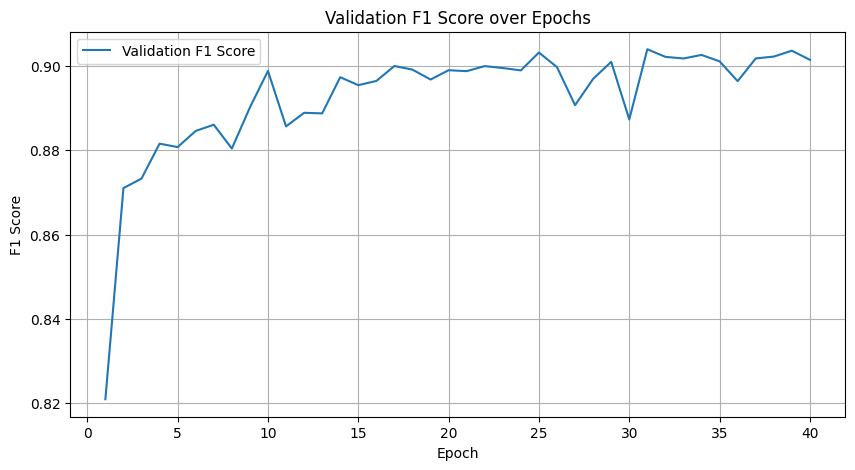

Plots saved to /content/drive/MyDrive/Colab_Notebooks/saved_models/plots
Training completed. Best model saved at: /content/drive/MyDrive/Colab_Notebooks/saved_models/UnetPlusPlus_resnet34_best_model.pth
Optimized threshold from training: 0.10

Generating Submission File...
Loaded model from /content/drive/MyDrive/Colab_Notebooks/saved_models/UnetPlusPlus_resnet34_best_model.pth
Using optimized threshold for submission: 0.10
Saving predicted masks...


<ipython-input-12-d3c197c0e29f>:1532: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_location=device))


Predicted masks saved to: /content/drive/MyDrive/Colab_Notebooks/predicted_masks
Generating submission file...
Submission file generated and saved to: /content/drive/MyDrive/Colab_Notebooks/submission.csv


In [ ]:
# ========================
# Transformation Functions
# ========================

def D4_transformations(image, debug=False):
    """
    Applies all 7 non-trivial transformations of the D4 dihedral group to an image.

    Parameters:
        image (PIL.Image.Image or torch.Tensor): Input image (PIL or PyTorch tensor).
        debug (bool): If True, displays all transformations alongside the original image.

    Returns:
        list: List of transformed tensors (7 non-trivial transformations).
    """

    # Ensure the image is a PyTorch tensor
    if isinstance(image, Image.Image):
        image = ToTensor()(image)

    if not isinstance(image, torch.Tensor):
        raise TypeError("Input must be a PIL.Image or a torch.Tensor.")

    # Determine shape of the image
    shape_len = image.ndim  # Number of dimensions

    # Ensure valid shape
    if shape_len not in {3, 4}:
        raise ValueError(f"Unsupported image shape: {image.shape}. Expected (C, H, W) or (N, C, H, W).")

    # List to store non-trivial transformations
    transformations = []

    # Define dimension indices based on the image shape
    if shape_len == 3:  # Single image: (C, H, W)
        dims_rotation = [1, 2]
        dims_horizontal_flip = [2]
        dims_vertical_flip = [1]
    elif shape_len == 4:  # Batched images: (N, C, H, W)
        dims_rotation = [2, 3]
        dims_horizontal_flip = [3]
        dims_vertical_flip = [2]

    # 90°, 180°, 270° rotations
    transformations.append(torch.rot90(image, k=1, dims=dims_rotation))  # Rotate 90°
    transformations.append(torch.rot90(image, k=2, dims=dims_rotation))  # Rotate 180°
    transformations.append(torch.rot90(image, k=3, dims=dims_rotation))  # Rotate 270°

    # Horizontal and vertical flips
    transformations.append(torch.flip(image, dims=dims_horizontal_flip))  # Horizontal flip
    transformations.append(torch.flip(image, dims=dims_vertical_flip))    # Vertical flip

    # Diagonal flips
    if shape_len == 3:  # Single image
        transformations.append(image.transpose(1, 2))  # Main diagonal flip
        transformations.append(torch.flip(image.transpose(1, 2), dims=[1]))  # Anti-diagonal flip
    elif shape_len == 4:  # Batched images
        transformations.append(image.transpose(2, 3))  # Main diagonal flip
        transformations.append(torch.flip(image.transpose(2, 3), dims=[2]))  # Anti-diagonal flip

    # Debugging: Display transformations alongside the original image
    if debug:
        to_pil = ToPILImage()
        image_cpu = image.cpu()
        transformations_cpu = [t.cpu() for t in transformations]
        num_transformations = len(transformations_cpu) + 1  # Original + 7 transformations
        num_cols = 4
        num_rows = (num_transformations + num_cols - 1) // num_cols  # Calculate rows dynamically

        fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 6))  # Dynamic rows x fixed columns
        fig.suptitle("D4 Transformations (Original + Non-Trivial)", fontsize=16)
        axes = axes.flatten()  # Flatten the axes for easy indexing

        # Titles for each transformation
        titles = [
            "Original", "90° Rotation", "180° Rotation", "270° Rotation",
            "Horizontal Flip", "Vertical Flip", "Diagonal Flip", "Anti-Diagonal Flip"
        ]

        # Display the original image in the first subplot
        axes[0].imshow(to_pil(image_cpu[0] if shape_len == 4 else image_cpu))
        axes[0].set_title(titles[0])
        axes[0].axis("off")

        # Display the non-trivial transformations
        for i, transformed_image in enumerate(transformations_cpu):
            axes[i + 1].imshow(to_pil(transformed_image[0] if shape_len == 4 else transformed_image))
            axes[i + 1].set_title(titles[i + 1])
            axes[i + 1].axis("off")

        # Hide unused subplots
        for j in range(num_transformations, len(axes)):
            axes[j].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    return transformations  # List of transformed images (tensors)

def forty_five_deg_rot(image, is_mask=False, debug=False):
    """
    Generates four rotated versions of an image (45°, 135°, 225°, 315°).

    Parameters:
        image (PIL.Image.Image or torch.Tensor): Input image (PIL or PyTorch tensor).
        is_mask (bool): If True, use nearest neighbor interpolation for masks.
        debug (bool): If True, displays the original and rotated images.

    Returns:
        list: A list of rotated tensors (45°, 135°, 225°, 315°).
    """
    # Ensure the image is a PyTorch tensor
    if isinstance(image, Image.Image):
        image = ToTensor()(image)

    if not isinstance(image, torch.Tensor):
        raise TypeError("Input must be a PIL.Image or a torch.Tensor.")

    # Add batch dimension if necessary
    if image.ndim == 3:
        image = image.unsqueeze(0)  # Shape: (1, C, H, W)

    N, C, H, W = image.shape

    # Prepare rotations
    rotations = []
    angles = [45, 135, 225, 315]  # Angles in degrees
    for angle in angles:
        angle_rad = -torch.tensor(angle, dtype=torch.float32) * torch.pi / 180  # Negative for clockwise rotation

        # Create rotation matrix
        theta = torch.tensor([
            [torch.cos(angle_rad), -torch.sin(angle_rad), 0],
            [torch.sin(angle_rad),  torch.cos(angle_rad), 0]
        ], dtype=torch.float32).unsqueeze(0)  # Shape: (1, 2, 3)

        theta = theta.repeat(N, 1, 1)  # Shape: (N, 2, 3)

        # Generate grid and perform sampling
        #grid = F.affine_grid(theta, size=image.size(), align_corners=False)
        grid = F.affine_grid(theta, size=(N, C, H, W), align_corners=False)

        rotated_image = F.grid_sample(
            image,
            grid,
            align_corners=False,
            mode='nearest' if is_mask else 'bilinear',
            padding_mode='zeros'
        )
        rotations.append(rotated_image.squeeze(0))  # Remove batch dimension

    # Debugging: Display original and rotated images
    if debug:
        to_pil = ToPILImage()
        image_cpu = image.cpu()
        rotations_cpu = [r.cpu() for r in rotations]
        num_images = len(rotations_cpu) + 1
        fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
        fig.suptitle("45° Rotations (Original + Rotated Images)", fontsize=16)

        # Display the original image
        axes[0].imshow(to_pil(image_cpu[0]))
        axes[0].set_title("Original")
        axes[0].axis("off")

        # Display rotated images
        for i, rotated_image in enumerate(rotations_cpu):
            axes[i + 1].imshow(to_pil(rotated_image))
            axes[i + 1].set_title(f"{angles[i]}°")
            axes[i + 1].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    return rotations  # List of rotated images (tensors)

# ===================================
# Utility Functions and Device Setup
# ===================================

def initialize_device():
    """
    Initialize the device to use for training (GPU if available, else CPU).

    Returns:
        torch.device: The device to use.
    """
    if torch.cuda.is_available():
        device = torch.device("cuda:0")  # Use the first GPU
        print(f"Using device: {device}")
    else:
        device = torch.device("cpu")  # Fallback to CPU
        print("CUDA is not available. Using CPU.")
    return device

def save_best_model(model, best_f1_score, current_f1_score, save_path, model_name, verbose=True):
    """
    Save the model if the current F1 score is better than the best F1 score.

    Parameters:
        model (torch.nn.Module): The model to save.
        best_f1_score (float): The best F1 score achieved so far.
        current_f1_score (float): The F1 score from the current epoch.
        save_path (str): The directory path to save the model.
        model_name (str): The name of the model file.

    Returns:
        float: The updated best F1 score.
    """
    if current_f1_score > best_f1_score:
        best_f1_score = current_f1_score
# Ensure the directory specified by `save_path` exists.
# - If the directory already exists, `exist_ok=True` prevents an error from being raised.
# - If the directory does not exist, it will be created automatically.
        os.makedirs(save_path, exist_ok=True)
        model_save_path = os.path.join(save_path, model_name)
# Save the model's current state (weights, biases, etc.) to a file in the `save_path` directory.
# - `model.state_dict()`: Retrieves a dictionary containing the model's trainable parameters
#   and persistent buffers (e.g., running statistics for batch normalization).
# - `os.path.join(save_path, model_name)`: Constructs the full file path where the model's state
#   will be saved, combining the directory path (`save_path`) and the file name (`model_name`).
# - `torch.save(...)`: Serializes and writes the model's state dictionary to the specified file.
        torch.save(model.state_dict(), model_save_path)
        print(f"Saved new best model with F1 score: {best_f1_score:.4f}") if verbose else None
    return best_f1_score

# ========================
# Plotting Function
# ========================

def save_and_show_plots(epochs, train_losses, val_losses, f1_scores, output_dir="plots"):
    """
    Display training and validation loss and F1 score plots, and save them as EPS files.

    Parameters:
        epochs (int): Number of training epochs.
        train_losses (list): List of training loss values.
        val_losses (list): List of validation loss values.
        f1_scores (list): List of validation F1 score values.
        output_dir (str): Directory to save the plots as EPS files.
    """
    os.makedirs(output_dir, exist_ok=True)

    # Plot Training and Validation Losses
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
    plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss over Epochs')
    plt.legend()
    plt.grid(True)
    # Save the plot as EPS
    plt.savefig(os.path.join(output_dir, "loss_plot.eps"), format='eps')
    # Show the plot
    plt.show()
    plt.close()

    # Plot Validation F1 Scores
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, epochs + 1), f1_scores, label='Validation F1 Score')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.title('Validation F1 Score over Epochs')
    plt.legend()
    plt.grid(True)

    # Save the plot as EPS
    plt.savefig(os.path.join(output_dir, "f1_score_plot.eps"), format='eps')
    # Show the plot
    plt.show()
    plt.close()


# ======================
# Custom Dataset Class
# ======================

class PadToMultiple:
    def __init__(self, multiple_or_encoder=None):
        """
        Dynamically determine padding multiple based on encoder requirements or use provided integer.

        Args:
            multiple_or_encoder (int or str): Either the padding multiple (int) or encoder name (str).
        """
        if isinstance(multiple_or_encoder, int):
            # Directly use the given integer
            self.multiple = multiple_or_encoder
        elif isinstance(multiple_or_encoder, str):
            # Dynamically set based on encoder name
            if "mobilenet" in multiple_or_encoder or "vgg" in multiple_or_encoder or "res2net" in multiple_or_encoder:
                self.multiple = 16
            else:
                self.multiple = 32
        elif multiple_or_encoder is None:
            # Default to 32 if no value is provided
            self.multiple = 32
        else:
            raise TypeError("multiple_or_encoder must be an int, str, or None.")

    def __call__(self, img):
        """
        Pad the image to ensure dimensions are multiples of the required factor.

        Args:
            img (torch.Tensor or PIL.Image): Input image.

        Returns:
            torch.Tensor: Padded image.
        """
        if isinstance(img, Image.Image):
            img = ToTensor()(img)

        if not isinstance(img, torch.Tensor):
            raise TypeError("Input must be a PIL.Image or torch.Tensor.")

        _, h, w = img.shape
        pad_h = (self.multiple - h % self.multiple) % self.multiple
        pad_w = (self.multiple - w % self.multiple) % self.multiple
        padding = (0, pad_w, 0, pad_h)  # Left, Right, Top, Bottom

        return F.pad(img, padding, mode="constant", value=0)

def get_transforms(encoder_name, mean, std):
    """
    Generate image and mask transform pipelines with dynamic padding.

    Args:
        encoder_name (str): The name of the encoder to determine padding multiple.
        mean (list): Mean values for normalization.
        std (list): Standard deviation values for normalization.

    Returns:
        tuple: image_transform (Compose), mask_transform (PadToMultiple)
    """
    pad_to_multiple = PadToMultiple(encoder_name)
    image_transform = Compose([
        pad_to_multiple,
        Normalize(mean=mean, std=std)
    ])
    mask_transform = PadToMultiple(encoder_name)
    return image_transform, mask_transform



def compute_mean_std(dataset, batch_size=64, num_workers=4):
    """
    Compute the mean and standard deviation for a given dataset.

    Parameters:
        dataset (Dataset): PyTorch Dataset object with images.
        batch_size (int): Batch size for DataLoader.
        num_workers (int): Number of subprocesses to use for data loading.

    Returns:
        tuple: mean (list of floats), std (list of floats)
    """
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    mean = 0.0
    std = 0.0
    total_samples = 0

    for images, _ in dataloader:  # Assuming dataset returns (image, label/mask)
        batch_samples = images.size(0)  # Number of images in the batch
        images = images.view(batch_samples, images.size(1), -1)  # Flatten H x W
        mean += images.mean(2).sum(0)  # Sum mean over batch
        std += images.std(2).sum(0)  # Sum std over batch
        total_samples += batch_samples

    mean /= total_samples
    std /= total_samples
    return mean.tolist(), std.tolist()

# NOTE: Dynamic Augmentation (Potential Alternative)
# -----------------------------------------------
# Dynamic augmentation applies transformations on-the-fly during each training epoch.
# Instead of precomputing all augmented samples, this approach randomly applies
# a single transformation to each sample every time it is accessed.
#
# Advantages of Dynamic Augmentation:
# 1. Simulates Diversity:
#    - The dataset size remains constant, but each epoch exposes the model
#      to slightly different versions of the data, improving generalization.
# 2. Saves Memory:
#    - No need to store multiple augmented copies of each sample in memory.
#    - Transformations are applied dynamically, reducing the dataset's memory footprint.
#
# Limitation of Dynamic Augmentation:
# - It does NOT increase the dataset size.
#   Instead, the number of training samples stays the same, but their appearance
#   changes slightly in each epoch.
#
# In this implementation, we use precomputed augmentation to increase the
# dataset size explicitly. Dynamic augmentation could be considered later if:
# - Memory constraints are an issue.
# - Randomness across epochs is desirable.
#
# Use the following in the `__getitem__` method if you decide to
# implement dynamic augmentation in the future:
#
# if self.use_d4:
#     image, mask = random.choice(list(zip(D4_transformations(image), D4_transformations(mask))))
# if self.use_rot45:
#     image, mask = random.choice(list(zip(forty_five_deg_rot(image), forty_five_deg_rot(mask, is_mask=True))))



class Train_Dataset(Dataset):
    """
    Custom dataset class for precomputing all augmented examples.

    This implementation increases the effective dataset size by precomputing all augmented
    versions of each image/mask pair during dataset initialization. Unlike dynamic augmentation,
    where transformations are applied on-the-fly during training, this approach explicitly
    creates and stores all augmentations upfront. This ensures that every augmented version
    is included as a separate training sample, avoiding randomness across epochs.

    Parameters:
        train_images_dir (str): Directory containing training images.
        train_masks_dir (str): Directory containing corresponding masks.
        transform (callable, optional): A function/transform to apply to the images and masks.
        use_d4 (bool): Whether to apply D4 transformations.
        use_rot45 (bool): Whether to apply 45-degree rotations.
    """
    def __init__(self, train_images_dir, train_masks_dir, image_transform=None, mask_transform=None, use_d4=False, use_rot45=False):
        # Store directory paths and augmentation options
        self.images_dir = train_images_dir
        self.masks_dir = train_masks_dir
        self.image_transform = image_transform
        self.mask_transform = mask_transform
        self.use_d4 = use_d4
        self.use_rot45 = use_rot45

        # List and sort all image and mask filenames to ensure alignment
        self.image_names = sorted(os.listdir(train_images_dir))
        self.mask_names = sorted(os.listdir(train_masks_dir))

        # Assert that there is a one-to-one correspondence between images and masks
        assert len(self.image_names) == len(self.mask_names), "Mismatch between number of images and masks."

        # Precompute all augmented samples and store them as tuples of (image, mask)
        # This step significantly increases the dataset size by adding augmented versions.
        self.samples = self._generate_augmented_samples()

    def _generate_augmented_samples(self):
        """
        Generate augmented samples for all images and masks.

        This method applies D4 transformations, 45-degree rotations, and any other desired
        augmentations to each image/mask pair and stores all augmented versions in a list.

        Returns:
            samples (list of tuples): List of (image, mask) pairs, where each pair represents
                                      an augmented version of the original data.
        """
        samples = []  # To store all (image, mask) pairs including augmented versions

        # Loop over each image and corresponding mask
        for img_name, mask_name in zip(self.image_names, self.mask_names):
            # Load the image and mask
            img_path = os.path.join(self.images_dir, img_name)
            mask_path = os.path.join(self.masks_dir, mask_name)
            image = Image.open(img_path).convert("RGB")  # Ensure RGB format
            mask = Image.open(mask_path).convert("L")    # Ensure grayscale format

            # Initialize lists to store augmented versions
            images, masks = [image], [mask]  # Start with original image and mask

            # Apply D4 transformations if enabled (rotations and flips)
            if self.use_d4:
                d4_images = D4_transformations(image)
                d4_masks = D4_transformations(mask)
                images.extend(d4_images)  # Add D4 augmented images
                masks.extend(d4_masks)    # Add corresponding masks

            # Apply 45-degree rotations if enabled
            if self.use_rot45:
                rot_images = forty_five_deg_rot(image)
                rot_masks = forty_five_deg_rot(mask, is_mask=True)
                images.extend(rot_images)  # Add rotated images
                masks.extend(rot_masks)    # Add corresponding masks

            # Combine augmented images and masks as tuples
            samples.extend(list(zip(images, masks)))

        return samples  # Return all augmented samples

    def __len__(self):
        """
        Return the total number of samples in the dataset.

        This includes the original images and all augmented versions.
        """
        return len(self.samples)

    def __getitem__(self, idx):
        """
        Retrieve a single image-mask pair by index.

        Parameters:
            idx (int): Index of the sample to retrieve.

        Returns:
            image (torch.Tensor): Transformed image tensor of shape (C, H, W).
            mask (torch.Tensor): Transformed mask tensor of shape (1, H, W).
        """
        # Retrieve the augmented image-mask pair from precomputed samples
        image, mask = self.samples[idx]

        # Convert to tensors if they are not already tensors
        if not isinstance(image, torch.Tensor):
            image = ToTensor()(image)
        if not isinstance(mask, torch.Tensor):
            mask = ToTensor()(mask)

        # Binarize the mask
        mask = (mask > 0.5).float()

        # Apply additional transformations
        if self.image_transform:
            image = self.image_transform(image)
        if self.mask_transform:
            mask = self.mask_transform(mask)

        return image, mask  # Return transformed tensors

def generate_submission_from_masks(mask_dir, submission_filename, foreground_threshold=0.5):
    """
    Generate a submission file from saved mask images.

    Args:
        mask_dir (str): Directory containing predicted mask images.
        submission_filename (str): Output submission file name.
        foreground_threshold (float): Threshold for binary classification.
    """
    def patch_to_label(patch):
        return 1 if np.mean(patch) > foreground_threshold else 0

    def mask_to_submission_strings(image_filename):
        img_number = int(re.search(r"\d+", image_filename).group(0))
        im = plt.imread(image_filename)
        patch_size = 16
        for j in range(0, im.shape[1], patch_size):
            for i in range(0, im.shape[0], patch_size):
                patch = im[i:i + patch_size, j:j + patch_size]
                label = patch_to_label(patch)
                yield f"{img_number:03d}_{j}_{i},{label}"

    # Collect all mask filenames
    mask_filenames = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith("_mask.png")])

    # Write submission file
    with open(submission_filename, "w") as f:
        f.write("id,prediction\n")
        for mask_filename in mask_filenames:
            f.writelines(f"{s}\n" for s in mask_to_submission_strings(mask_filename))


def save_predicted_masks(model, test_loader, device, threshold=0.5, output_dir="predicted_masks"):
    """
    Save predicted masks as .png images.

    Args:
        model (torch.nn.Module): Trained model.
        test_loader (DataLoader): DataLoader for the test dataset.
        device (torch.device): Device to use for computation.
        threshold (float): Threshold for binary predictions.
        output_dir (str): Directory to save predicted masks.
    """
    model.eval()
    os.makedirs(output_dir, exist_ok=True)

    with torch.no_grad():
        for batch_idx, (images, image_ids) in enumerate(test_loader):
            images = images.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > threshold).cpu().numpy().astype(np.uint8) * 255

            # Save each predicted mask as a .png file
            for i, image_id in enumerate(image_ids):
                mask = preds[i, 0]  # Single-channel mask
                mask_path = os.path.join(output_dir, f"{image_id}_mask.png")
                Image.fromarray(mask).save(mask_path)



# Custom Test Dataset
class Test_Dataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_names = sorted(os.listdir(image_dir))

    def __len__(self):
      return len(self.image_names)


    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Return the image and its ID (without extension)
        return image, os.path.splitext(img_name)[0]


# =========================
# Model Definition (Unet++)
# =========================
def get_smp_model(architecture='UnetPlusPlus', encoder_name='resnet50',
                  in_channels=3, classes=1, encoder_weights='imagenet'):
    """
    Generalized function to initialize segmentation models from segmentation_models_pytorch (smp).

    Parameters:
        architecture (str): Segmentation architecture ('Unet', 'UnetPlusPlus', 'DeepLabV3', 'DeepLabV3Plus', 'PAN', 'FPN').
        encoder_name (str): Encoder backbone to use.
        in_channels (int): Number of input channels (e.g., 3 for RGB).
        classes (int): Number of output classes.
        encoder_weights (str): Pretrained weights to use ('imagenet', 'noisy-student', or None).

    Returns:
        torch.nn.Module: The initialized segmentation model.
    """
    architecture_map = {
        'Unet': smp.Unet,
        'UnetPlusPlus': smp.UnetPlusPlus,
        'DeepLabV3': smp.DeepLabV3,
        'DeepLabV3Plus': smp.DeepLabV3Plus,
        'PAN': smp.PAN,
        'FPN': smp.FPN,
    }

    if architecture not in architecture_map:
        raise ValueError(f"Unsupported architecture '{architecture}'. Available options: {list(architecture_map.keys())}")

    # Check if dilation needs to be disabled for certain encoders
    encoder_output_stride = 32  # Default stride
    if architecture in ['DeepLabV3', 'DeepLabV3Plus'] and 'resnet' in encoder_name:
        encoder_output_stride = 16  # Avoid dilated mode for ResNet encoders

    # Initialize the model with specified pretrained weights
    model = architecture_map[architecture](
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=in_channels,
        classes=classes,
        encoder_output_stride=encoder_output_stride,  # Controls dilation behavior
        activation=None
    )
    return model




# =========================
# Training and Evaluation
# =========================
def Jaccard_index(pred, ground_truth, threshold=0.5):
    """
    Calculate the intersection over union (IoU) score using BinaryJaccardIndex from torchmetrics.

    Args:
        pred (torch.Tensor): Predicted binary values (probabilities or logits).
        ground_truth (torch.Tensor): Ground truth binary values.
        threshold (float): Threshold for converting predicted probabilities/logits to binary values.

    Returns:
        float: Intersection over union score.
    """
    # Ensure tensors are on the same device
    device = pred.device
    ground_truth = ground_truth.to(device)

    # Apply threshold to predictions
    pred = (pred > threshold).float()

    # Initialize IoU metric
    metric = BinaryJaccardIndex().to(device)

    # Compute IoU
    iou_score = metric(pred, ground_truth)

    return iou_score.item()

def F1_score(pred, ground_truth, threshold=0.5):
    """
    Calculate the F1 score using BinaryF1Score from torchmetrics.

    Args:
        pred (torch.Tensor): Predicted binary values (probabilities or logits).
        ground_truth (torch.Tensor): Ground truth binary values.
        threshold (float): Threshold for converting predicted probabilities/logits to binary values.

    Returns:
        float: F1 score.
    """
    # Ensure tensors are on the same device
    device = pred.device
    ground_truth = ground_truth.to(device)

    # Apply threshold to predictions
    pred = (pred > threshold).float()

    # Initialize BinaryF1Score metric and move it to the correct device
    metric = BinaryF1Score().to(device)

    # Compute F1 score
    f1_score = metric(pred, ground_truth)

    return f1_score.item()  # Convert tensor to Python float for easier interpretation


def evaluate(model, val_dataloader, criterion, device, threshold=0.5):
    """
    Evaluate the model on the validation set and compute loss, F1 score, and IoU using external functions.

    Args:
        model (torch.nn.Module): The segmentation model to evaluate.
        val_dataloader (torch.utils.data.DataLoader): Validation dataset loader.
        criterion (callable): Loss function.
        device (torch.device): Device to use for computation.
        threshold (float): Threshold for binary classification.

    Returns:
        tuple: Average validation loss, F1 score, and IoU score.
    """
    model.eval()
    val_loss = 0.0
    total_iou = 0.0
    total_f1 = 0.0
    num_batches = 0

    with torch.no_grad():
        for images, masks in val_dataloader:
            images, masks = images.to(device), masks.to(device)

            # Forward pass
            with torch.autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, masks.float())
            val_loss += loss.item()

            # Predictions
            preds = torch.sigmoid(outputs)

            # Compute metrics using external functions
            batch_iou = Jaccard_index(preds, masks, threshold)  # Compute IoU
            batch_f1 = F1_score(preds, masks, threshold)        # Compute F1 score

            total_iou += batch_iou
            total_f1 += batch_f1
            num_batches += 1

    avg_val_loss = val_loss / len(val_dataloader)
    avg_iou_score = total_iou / num_batches
    avg_f1_score = total_f1 / num_batches

    return avg_val_loss, avg_f1_score, avg_iou_score


def tune_thresholds(model, val_dataloader, device, thresholds, criterion=None):
    """
    Evaluate multiple thresholds for F1 score and return the best-performing threshold.

    Parameters:
        model (torch.nn.Module): Trained model to evaluate.
        val_dataloader (DataLoader): DataLoader for validation data.
        device (torch.device): Device (CPU/GPU) to use for computation.
        thresholds (list of float): List of thresholds to evaluate.
        criterion (callable, optional): Loss function used during validation (not used here).

    Returns:
        dict: Dictionary mapping thresholds to their average F1 scores.
              Example: {threshold: F1_score}.
    """
    # Set the model to evaluation mode to disable dropout and batch normalization
    model.eval()

    # Store F1 scores for each threshold
    threshold_f1_scores = {}

    # Progress bar for evaluating thresholds
    with tqdm(total=len(thresholds), desc="Evaluating Thresholds", leave=False, position=2) as pbar:
        with torch.no_grad():
            for threshold in thresholds:
                total_f1 = 0.0  # Cumulative F1 score for the current threshold
                total_batches = 0  # Track the number of batches processed

                # Iterate over validation dataset
                for images, masks in val_dataloader:
                    images, masks = images.to(device), masks.to(device)
                    outputs = model(images)  # Get model predictions (logits)
                    preds = torch.sigmoid(outputs) > threshold  # Apply threshold

                    # Compute F1 score for the batch
                    batch_f1 = F1_score(preds, masks, threshold)
                    total_f1 += batch_f1
                    total_batches += 1

                # Store the average F1 score for this threshold
                avg_f1 = total_f1 / total_batches
                threshold_f1_scores[threshold] = avg_f1

                # Update the progress bar with threshold and F1 score
                pbar.set_postfix({"Threshold": f"{threshold:.2f}", "Avg F1": f"{avg_f1:.4f}"})
                pbar.update(1)

    return threshold_f1_scores  # Dictionary mapping thresholds to average F1 scores





@dataclass
class TrainingConfig:
    model: torch.nn.Module
    train_dataloader: DataLoader
    val_dataloader: DataLoader
    epochs: int
    optimizer: torch.optim.Optimizer
    criterion: callable
    device: torch.device
    scheduler: torch.optim.lr_scheduler.ReduceLROnPlateau
    save_path: str = "/content/drive/MyDrive/saved_models"  # Save models to Google Drive
    model_name: str = f"model_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"  # Name of the saved model
    gradient_clipping: bool = True
    max_norm: float = 1.0

def train(config: TrainingConfig):
    """
    Main training loop with progress tracking, validation, and dynamic threshold optimization.
    """
    # Extract inputs from the training configuration
    model = config.model
    train_dataloader = config.train_dataloader
    val_dataloader = config.val_dataloader
    epochs = config.epochs
    optimizer = config.optimizer
    criterion = config.criterion
    device = config.device
    scheduler = config.scheduler
    save_path = config.save_path
    model_name = config.model_name
    gradient_clipping = config.gradient_clipping
    max_norm = config.max_norm

    # Initialize variables for tracking progress
    best_f1_score = 0.0
    best_iou_score = 0.0
    best_threshold = 0.5
    best_threshold_epoch = 1
    best_model_path = None
    train_losses, val_losses = [], []
    f1_scores, iou_scores = [], []

    # Initial threshold range
    thresholds = [i / 100 for i in range(10, 90, 5)]  # Initial range: 0.1 to 0.85 with step 0.05

    # Mixed precision setup
    use_amp = torch.cuda.is_available()
    scaler = GradScaler(enabled=use_amp) if use_amp else None

    # Outer progress bar for total epochs
    with tqdm(total=epochs, desc="Total Training Progress", leave=True, position=0) as epoch_bar:
        for epoch in range(epochs):
            print(f"\nEpoch [{epoch + 1}/{epochs}]")

            # -----------------------
            # Training Phase
            # -----------------------
            model.train()
            train_loss = 0.0
            with tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{epochs} Training", leave=False, position=1) as batch_bar:
                for images, masks in batch_bar:
                    images, masks = images.to(device), masks.to(device)
                    optimizer.zero_grad()

                    # Forward pass with mixed precision
                    with torch.autocast(device_type="cuda" if use_amp else "cpu", enabled=use_amp):
                        outputs = model(images)
                        loss = criterion(outputs, masks.float())

                    # Backward pass and optimization
                    scaler.scale(loss).backward()
                    if gradient_clipping:
                        scaler.unscale_(optimizer)
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)
                    scaler.step(optimizer)
                    scaler.update()

                    train_loss += loss.item()

            avg_train_loss = train_loss / len(train_dataloader)
            train_losses.append(avg_train_loss)

            # -----------------------
            # Validation Phase
            # -----------------------
            val_loss, current_f1_score, current_iou_score = evaluate(
                model, val_dataloader, criterion, device, threshold=best_threshold
            )
            val_losses.append(val_loss)
            f1_scores.append(current_f1_score)
            iou_scores.append(current_iou_score)

            # -----------------------
            # Threshold Optimization
            # -----------------------
            if epoch % 10 == 0 or epoch == epochs - 1:  # Tune every 5 epochs and at the last epoch
                threshold_results = tune_thresholds(model, val_dataloader, device, thresholds, criterion)
                best_threshold_epoch = max(threshold_results, key=threshold_results.get)
                tqdm.write(f"Best threshold for Epoch {epoch + 1}: {best_threshold_epoch:.2f}")

                # Dynamically adjust thresholds around the best threshold
                delta = 0.05  # Narrow range
                new_min = max(0.0, best_threshold_epoch - delta)  # Avoid going below 0
                new_max = min(1.0, best_threshold_epoch + delta)  # Avoid exceeding 1
                thresholds = [round(i, 3) for i in torch.arange(new_min, new_max, 0.01).tolist()]
                tqdm.write(f"Updated threshold range: {thresholds}")

            # Update the learning rate scheduler
            scheduler.step(current_f1_score)

            # Save the model if it achieves a new best F1 score
            if current_f1_score > best_f1_score:
                best_f1_score = current_f1_score
                best_iou_score = current_iou_score
                best_threshold = best_threshold_epoch
                os.makedirs(save_path, exist_ok=True)
                best_model_path = os.path.join(save_path, model_name)
                torch.save(model.state_dict(), best_model_path)
                print(f"Saved new best model to {best_model_path} with F1 Score: {best_f1_score:.4f}")

            # Save the best threshold to a file in the same directory as the model
            threshold_file_path = os.path.join(save_path, "best_threshold.txt")
            if best_threshold_epoch != best_threshold:
              best_threshold = best_threshold_epoch
            with open(threshold_file_path, "w") as f:
                f.write(f"{best_threshold:.4f}")


            # -----------------------
            # Summary of the Epoch
            # -----------------------
            print(f"Epoch [{epoch + 1}/{epochs}] Summary:")
            print(f"Train Loss: {avg_train_loss:.4f}")
            print(f"Validation Loss: {val_loss:.4f}")
            print(f"Validation F1 Score: {current_f1_score:.4f}")
            print(f"Validation IoU Score: {current_iou_score:.4f}")
            print(f"Best Threshold So Far: {best_threshold:.2f}")
            print(f"Best F1 Score So Far: {best_f1_score:.4f} (IoU: {best_iou_score:.4f})")

            # Update the outer progress bar
            epoch_bar.update(1)
            epoch_bar.set_postfix({"Val Loss": f"{val_loss:.4f}", "Best F1": f"{best_f1_score:.4f}"})

    # -----------------------
    # Plot and Save Results
    # -----------------------

    # After training is complete
    print("\nGenerating final training plots...")
    plots_dir = os.path.join(save_path, "plots")
    save_and_show_plots(
        epochs=config.epochs,
        train_losses=train_losses,
        val_losses=val_losses,
        f1_scores=f1_scores,
        output_dir=plots_dir
    )
    print(f"Plots saved to {plots_dir}")

    # Return the best model path and threshold
    return best_model_path, best_threshold





# =========================
# Optuna Hyperparameter Optimization
# =========================

def train_with_optuna(config: TrainingConfig, trial):
    """Training loop adapted for Optuna hyperparameter optimization."""
    # INPUTS
    ####################################
    model = config.model
    train_dataloader = config.train_dataloader
    val_dataloader = config.val_dataloader
    epochs = config.epochs
    optimizer = config.optimizer
    criterion = config.criterion
    device = config.device
    scheduler = config.scheduler
    save_path = config.save_path
    model_name = config.model_name
    gradient_clipping = config.gradient_clipping
    max_norm = config.max_norm
    ####################################
    use_amp = torch.cuda.is_available()  # Enable AMP only if CUDA is available

    scaler = GradScaler() if use_amp else None
    best_f1_score = 0.0

    print(f"\nStarting trial {trial.number}")
    print(f"Trial {trial.number} Hyperparameters: {trial.params}")

    for epoch in tqdm( range(epochs), desc=f"Trial {trial.number + 1} Progress",leave=True, position=0):
        # Training phase
        model.train()
        train_loss = 0.0

        #for batch_idx, (images, masks) in enumerate(tqdm(train_dataloader, desc=f"Training Epoch {epoch + 1}/{epochs}", leave=False, position=1)):
        for batch_idx, (images, masks) in enumerate(tqdm(train_dataloader, desc=f"Training Epoch", leave=False, position=1)):
            images, masks = images.to(device), masks.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass and loss computation
            if use_amp:
                with autocast(device_type=device.type):
                    outputs = model(images)
                    loss = criterion(outputs, masks.float())
            else:
                outputs = model(images)
                loss = criterion(outputs, masks.float())

            # Backward pass and optimization
            if use_amp:
                scaler.scale(loss).backward()
                if gradient_clipping:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                if gradient_clipping:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)
                optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_dataloader)
        print(f"Epoch {epoch + 1} - Training Loss: {avg_train_loss:.4f}")

        # Validation phase
        val_loss, current_f1_score, current_iou_score = evaluate(model, val_dataloader, criterion, device)
        print(f"Epoch {epoch + 1} - Validation Loss: {val_loss:.4f}, F1 Score: {current_f1_score:.4f}, IoU: {current_iou_score:.4f}")


        # Update the learning rate scheduler
        scheduler.step(current_f1_score)

        # Save the best model
        best_f1_score = save_best_model(model, best_f1_score, current_f1_score, save_path, model_name, verbose=False)

        # Report intermediate objective value to Optuna
        trial.report(current_f1_score, epoch)

        # Handle pruning
        if trial.should_prune():
            print(f"Trial {trial.number} pruned at epoch {epoch + 1}")
            raise optuna.exceptions.TrialPruned()

    print(f"Trial {trial.number} completed with Best F1 Score: {best_f1_score:.4f}")
    return best_f1_score


def run_optuna_optimization(n_trials=20, optuna_n_Epochs=10):
    """
    Runs the Optuna hyperparameter optimization and analyzes the results.

    Parameters:
        n_trials (int): Number of trials for the Optuna study.
        optuna_n_Epochs (int): Number of epochs per trial.

    Returns:
        dict: The best hyperparameters found by the study.
    """
    def objective(trial):
        """Objective function for Optuna."""
        # Suggest hyperparameters
        weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
        learning_rate = trial.suggest_float('learning_rate', 1e-6, 1e-2, log=True)
        max_norm = trial.suggest_float('max_norm', 0.1, 10.0)
        patience = trial.suggest_int('patience', 3, 10)
        factor = trial.suggest_float('factor', 0.1, 0.9)
        batch_size = trial.suggest_categorical('batch_size', [4, 8, 16])
        loss_name = trial.suggest_categorical(
            'loss', ['DiceLoss', 'JaccardLoss', 'TverskyLoss', 'LovaszLoss', 'FocalLoss', 'DiceBCELoss']
        )

        # Architectures and encoders based on previous tests
        architecture = trial.suggest_categorical(
            'architecture', ['Unet', 'UnetPlusPlus', 'DeepLabV3Plus', 'PAN', 'FPN']
        )

        encoder_name = trial.suggest_categorical(
            'encoder_name', ['resnet50', 'resnet34','efficientnet-b4', 'mobilenet_v2', 'timm-res2net50_26w_4s', 'senet154']
        )

        # Prune known failing combos:
        # DeepLabV3Plus and PAN with timm-res2net50_26w_4s have known dilation issues
        if architecture in ['PAN', 'DeepLabV3Plus'] and encoder_name == 'timm-res2net50_26w_4s':
            raise optuna.exceptions.TrialPruned(f"Combination {architecture} with {encoder_name} not supported.")

        # Define the loss function
        if loss_name == 'DiceLoss':
            criterion = smp.losses.DiceLoss(mode="binary")
        elif loss_name == 'JaccardLoss':
            criterion = smp.losses.JaccardLoss(mode="binary")
        elif loss_name == 'TverskyLoss':
            alpha = trial.suggest_float('alpha', 0.3, 0.7)
            beta = trial.suggest_float('beta', 0.3, 0.7)
            criterion = smp.losses.TverskyLoss(mode="binary", alpha=alpha, beta=beta)
        elif loss_name == 'LovaszLoss':
            criterion = smp.losses.LovaszLoss(mode="binary")
        elif loss_name == 'FocalLoss':
            criterion = smp.losses.FocalLoss(mode="binary")
        elif loss_name == 'DiceBCELoss':
            dice_loss = smp.losses.DiceLoss(mode="binary")
            bce_loss = smp.losses.SoftBCEWithLogitsLoss()
            def combined_loss(pred, target):
                return 0.5 * dice_loss(pred, target) + 0.5 * bce_loss(pred, target)
            criterion = combined_loss

        # Initialize the model based on architecture and encoder
        if architecture == 'Unet':
            model = smp.Unet(encoder_name=encoder_name, in_channels=3, classes=1).to(device)
        elif architecture == 'UnetPlusPlus':
            model = smp.UnetPlusPlus(encoder_name=encoder_name, in_channels=3, classes=1).to(device)
        elif architecture == 'DeepLabV3Plus':
            model = smp.DeepLabV3Plus(encoder_name=encoder_name, in_channels=3, classes=1).to(device)
        elif architecture == 'PAN':
            model = smp.PAN(encoder_name=encoder_name, in_channels=3, classes=1).to(device)
        elif architecture == 'FPN':
            model = smp.FPN(encoder_name=encoder_name, in_channels=3, classes=1).to(device)

        # Define optimizer
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

        # Define scheduler
        scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=factor, patience=patience)

        # Update DataLoaders with the suggested batch size
        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=nb_w,
            pin_memory=True
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=nb_w,
            pin_memory=True
        )

        # Define training configuration
        config = TrainingConfig(
            model=model,
            train_dataloader=train_loader,
            val_dataloader=val_loader,
            epochs=optuna_n_Epochs,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            scheduler=scheduler,
            save_path="./saved_models",
            model_name=f"{architecture}_{encoder_name}_trial_{trial.number}.pth",
            gradient_clipping=True,
            max_norm=max_norm
        )

        # Train and evaluate
        try:
            best_f1_score = train_with_optuna(config, trial)
        except optuna.exceptions.TrialPruned:
            print(f"Trial {trial.number} was pruned.")
            raise optuna.exceptions.TrialPruned()

        return best_f1_score

    # Create an Optuna study
    study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())

    # Run optimization
    print("\nStarting Optuna Optimization")
    with tqdm(total=n_trials, desc="Optuna Progress") as pbar:
        def callback(study, trial):
            pbar.update(1)

    study.optimize(objective, n_trials=n_trials, callbacks=[callback])

    # Analyze results
    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    best_trial = study.best_trial
    print(f"  Best F1 Score: {best_trial.value}")
    print("  Best Hyperparameters:")
    for key, value in best_trial.params.items():
        if isinstance(value, (float, int)):
            print(f"    {key}: {value:.4f}")
        else:
            print(f"    {key}: {value}")

    return best_trial.params



# ========================
# Main Execution
# ========================
if __name__ == "__main__":
    # Conditional Import for Google Colab
    try:
        from google.colab import drive
        colab = True
    except ImportError:
        colab = False
        print("Running outside Google Colab. Skipping Google Drive setup.")

    if colab:
        print("Mounting Google Drive...")
        print()
        drive.mount('/content/drive')
    else:
        print("Running locally. Ensure your paths are configured correctly.")

    # Base directory setup
    if colab:
        BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/"
    else:
        BASE_DIR = os.path.dirname(os.path.abspath(__file__))  # Root directory of the project when using .py script
        #BASE_DIR = os.getcwd()  # Use current working directory for notebooks

    data_dir = os.path.join(BASE_DIR, "data")

    # Define paths for images and masks.
    mini = False  # Set to True if working with mini datasets ============================================================================================================================
    suffix = "_mini" if mini else ""
    train_images_dir = os.path.join(BASE_DIR if colab else data_dir, f"train_images{suffix}")
    train_masks_dir = os.path.join(BASE_DIR if colab else data_dir, f"train_masks{suffix}")
    validation_images_dir = os.path.join(BASE_DIR if colab else data_dir, f"validation_images{suffix}")
    validation_masks_dir = os.path.join(BASE_DIR if colab else data_dir, f"validation_masks{suffix}")

    # Path for saving models
    best_model_path = os.path.join(BASE_DIR, "saved_models")

    # Ensure the saved model directory exists
    os.makedirs(best_model_path, exist_ok=True)

    # ====================================================================================================================================================================================
    optuna_n_trials = 20   # Explore a good range of hyperparameters
    optuna_n_Epochs = 15   # Allow enough epochs per trial for meaningful evaluation
    train_n_epochs = 40   # Train for a sufficient number of epochs to fully optimize the final model

    optimise = False
    train_model = True
    create_submission = True
    # ====================================================================================================================================================================================

    # Count the number of images and masks
    num_train_images = len(os.listdir(train_images_dir))
    num_train_masks = len(os.listdir(train_masks_dir))
    num_val_images = len(os.listdir(validation_images_dir))
    num_val_masks = len(os.listdir(validation_masks_dir))

    # Print the counts
    print(f"Using Mini datasets : {mini}") if mini else None
    print(f" Number of training images: {num_train_images}")
    print(f" Number of training masks: {num_train_masks}")
    print(f" Number of validation images: {num_val_images}")
    print(f" Number of validation masks: {num_val_masks}")


    print(f"\nConfiguration, using Mini datasets : {mini}")
    print(f"  Perform Hyperparameter Optimization: {optimise}")
    if optimise:
        print(f"    Number of Optuna Trials: {optuna_n_trials}")
        print(f"    Number of Epochs per Trial: {optuna_n_Epochs}")
    print(f"Number of Epochs for Training: {train_n_epochs}")

    print(f"\nTrain the Model: {train_model}")
    print(f"Create Submission File: {create_submission}")
    print()


    # Step 1: Temporary Dataset for Computing Mean/Std
    temp_dataset = Train_Dataset(
        train_images_dir=train_images_dir,
        train_masks_dir=train_masks_dir,
        image_transform=None,
        mask_transform=None,
        use_d4=False,
        use_rot45=False
    )

    nb_w = 2
    # Step 2: Compute Mean and Std
    mean, std = compute_mean_std(temp_dataset, batch_size=64, num_workers=nb_w)
    #print(f"Computed Mean and Std for normalization: {[round(m, 3) for m in mean]}, {[round(s, 3) for s in std]}")



    # Step 3: Define Transform Pipelines for images
    pad_to_multiple = PadToMultiple()  # Default to 32 since encoder_name is not available yet

    image_transform = Compose([
        pad_to_multiple,  # Ensure dimensions are padded
        Normalize(mean=mean, std=std)
    ])
    # Transform for masks
    mask_transform = PadToMultiple(32)  # Only pad masks, masks are padded the same way ; no normalization

    # Step 4: Initialize Training and Validation Datasets
    train_dataset = Train_Dataset(
        train_images_dir=train_images_dir,
        train_masks_dir=train_masks_dir,
        image_transform=image_transform,
        mask_transform=mask_transform,
        use_d4=True,
        use_rot45=True
    )

    val_dataset = Train_Dataset(
        train_images_dir=validation_images_dir,
        train_masks_dir=validation_masks_dir,
        image_transform=image_transform,
        mask_transform=mask_transform,
        use_d4=True,
        use_rot45=False
    )

    # Step 5: Initialize Device
    device = initialize_device()

    # Step 6: Optimize or Load Best Hyperparameters
    if not optimise:
        # Define the path to the file containing the best parameters
        best_params_file = os.path.join(BASE_DIR, "saved_models", "best_hyperparameters.json")

        # Try to load best parameters from the file
        if os.path.exists(best_params_file):
            print(f"Loading best parameters from file: {best_params_file}")
            with open(best_params_file, "r") as f:
                best_params = json.load(f)
        else:
            # File does not exist, use default parameters
            print(f"File {best_params_file} not found. Using default hyperparameters.")
            best_params = {
                'weight_decay': 0.00001,
                'learning_rate': 0.0003,
                'max_norm': 1.4827,
                'patience': 5.0,
                'factor': 0.8668,
                'batch_size': 16,
                'loss': 'JaccardLoss',
                'encoder_name': 'resnet34',
                # Uncomment below if needed
                # 'alpha': 0.6,
                # 'beta': 0.4
            }

        print("Using best hyperparameters:", best_params)

    else:
        # Perform Optuna optimization
        print("\nStarting Optuna Optimization...")
        best_params_file = os.path.join(BASE_DIR, "saved_models", "best_hyperparameters.json")

        # Run Optuna and save the best parameters in the specified path
        best_params = run_optuna_optimization(n_trials=optuna_n_trials, optuna_n_Epochs=optuna_n_Epochs)

        # Save the best parameters for future use in saved_models
        os.makedirs(os.path.dirname(best_params_file), exist_ok=True)
        with open(best_params_file, "w") as f:
            json.dump(best_params, f)

        print(f"Saved best parameters to {best_params_file}")


    # Dynamically update transforms with encoder-specific padding requirements
    encoder_name = str(best_params['encoder_name'])  # Ensure encoder_name is a string
    image_transform, mask_transform = get_transforms(encoder_name, mean, std)

    # Reinitialize datasets with updated transforms
    train_dataset.image_transform = image_transform
    train_dataset.mask_transform = mask_transform

    val_dataset.image_transform = image_transform
    val_dataset.mask_transform = mask_transform

    # Step 7: Prepare DataLoaders with Best Batch Size
    train_loader = DataLoader(
        train_dataset,
        batch_size=best_params['batch_size'],
        shuffle=True,
        num_workers=nb_w,
        pin_memory=True,
        prefetch_factor=2
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=best_params['batch_size'],
        shuffle=False,
        num_workers=nb_w,
        pin_memory=True,
        prefetch_factor=2
    )

    # Step 8: Initialize the Model with Best Encoder
    model = get_smp_model(
        architecture=best_params.get('architecture', 'UnetPlusPlus'),  # dict.get(key, default_value) i.e UnetPlusPlus=default
        encoder_name=best_params['encoder_name']
    ).to(device)

    # Step 9: Define the Loss Function from Best Parameters
    if best_params['loss'] == 'DiceLoss':
      criterion = smp.losses.DiceLoss(mode="binary")
    elif best_params['loss'] == 'JaccardLoss':
      criterion = smp.losses.JaccardLoss(mode="binary")
    elif best_params['loss'] == 'TverskyLoss':
      criterion = smp.losses.TverskyLoss(
          mode="binary",
          alpha=best_params.get('alpha', 0.5),  # Use optimized alpha or default to 0.5
          beta=best_params.get('beta', 0.5)    # Use optimized beta or default to 0.5
      )
    elif best_params['loss'] == 'LovaszLoss':
       criterion = smp.losses.LovaszLoss(mode="binary")
    elif best_params['loss'] == 'FocalLoss':
       criterion = smp.losses.FocalLoss(mode="binary")
    elif best_params['loss'] == 'DiceBCELoss':
        dice_loss = smp.losses.DiceLoss(mode="binary")
        bce_loss = smp.losses.SoftBCEWithLogitsLoss()

        def combined_loss(pred, target):
            return 0.5 * dice_loss(pred, target) + 0.5 * bce_loss(pred, target)

        criterion = combined_loss
    else:
        raise ValueError(f"Unsupported loss type: {best_params['loss']}")

    # Step 10: Define Optimizer and Scheduler with Best Parameters
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=best_params['learning_rate'],
        weight_decay=best_params['weight_decay']
    )
    scheduler = ReduceLROnPlateau(
        optimizer, mode='max', factor=best_params['factor'], patience=best_params['patience']
    )

    # Step 11: Create Training Configuration
    config = TrainingConfig(
        model=model,
        train_dataloader=train_loader,
        val_dataloader=val_loader,
        epochs=train_n_epochs,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        scheduler=scheduler,
        save_path = best_model_path,
        model_name=f"{best_params.get('architecture', 'UnetPlusPlus')}_{best_params['encoder_name']}_best_model.pth",
        gradient_clipping=True,
        max_norm=best_params['max_norm']
    )

    # Step 12: Train the Model with Best Hyperparameters
    if train_model:
        best_model_path, best_threshold = train(config)
        print(f"Training completed. Best model saved at: {best_model_path}")
        print(f"Optimized threshold from training: {best_threshold:.2f}")

    else:
        save_path = best_model_path
        # If not training, ensure we can load the best threshold
        threshold_file_path = os.path.join(save_path, "best_threshold.txt")
        if os.path.exists(threshold_file_path):
            with open(threshold_file_path, "r") as f:
                best_threshold = float(f.read().strip())
            print(f"Loaded optimized threshold from file: {best_threshold:.2f}")
        else:
            # Default to 0.5 if the file is missing
            best_threshold = 0.5
            print(f"No optimized threshold file found. Defaulting to: {best_threshold:.2f}")

  # Step 13: Generate Submission File
    if create_submission:
        print("\nGenerating Submission File...")

        # Define paths
        test_images_dir = os.path.join(BASE_DIR if colab else data_dir, "test_set_images")  # Test image directory
        predicted_masks_dir = os.path.join(BASE_DIR if colab else data_dir, "predicted_masks")  # Directory to save predicted masks

        submission_file_path = os.path.join(BASE_DIR, "submission.csv")  # Directory to save Submission CSV file

        # Load test dataset
        test_dataset = Test_Dataset(image_dir=test_images_dir, transform=image_transform)
        test_loader = DataLoader(
            test_dataset,
            batch_size=1,  # Batch size of 1 ensures predictions for individual test images
            shuffle=False,
            num_workers=nb_w,
            pin_memory=True
        )



        # Dynamically construct the model file name using architecture and encoder_name
        model_name = f"{best_params.get('architecture', 'UnetPlusPlus')}_{best_params['encoder_name']}_best_model.pth"
        best_model_path = os.path.join(BASE_DIR, "saved_models", model_name) # Define the full path for saving the model

        # Load the trained model
        model = get_smp_model(
            architecture=best_params.get('architecture', 'UnetPlusPlus'),  # dict.get(key, default_value) i.e UnetPlusPlus=default
            encoder_name=best_params['encoder_name']
        ).to(device)

        model.load_state_dict(torch.load(best_model_path, map_location=device))
        print(f"Loaded model from {best_model_path}")

        # Use the dynamically optimized threshold for predictions
        print(f"Using optimized threshold for submission: {best_threshold:.2f}")

        # Save predicted masks
        print("Saving predicted masks...")
        save_predicted_masks(
            model=model,
            test_loader=test_loader,
            device=device,
            threshold=best_threshold,
            output_dir=predicted_masks_dir
        )
        print(f"Predicted masks saved to: {predicted_masks_dir}")

        # Generate the submission file
        print("Generating submission file...")
        generate_submission_from_masks(
            mask_dir=predicted_masks_dir,
            submission_filename=submission_file_path,
            foreground_threshold=best_threshold
        )
        print(f"Submission file generated and saved to: {submission_file_path}")